In [1]:
from sonogenetics.analysis.lib.analysis_params import dataset_dir, figure_dir_analysis, data_list
from sonogenetics.analysis.lib.data_io import DataIO
from sonogenetics.analysis.lib.display_tools import generate_raster_plots_session, generate_heatmaps_session, firing_rate_per_protocol_master

data_io = DataIO(r'E:\sono\dataset')
for s in data_io.sessions:
    print(s)



2025-02-16 mouse c57 566 eMSCL A
2026-02-11 mouse c57 565 eMSCL A
2026-02-16 mouse c57 566 eMSCL A
2026-02-19 mouse c57 5713 Mekano6 A
2026-03-17 mouse c57 613 eMSCL A
2026-03-25 mouse c57 617 Mekano6 A
2026-03-25 mouse c57 617 Mekano6 B
2026-03-25 mouse c57 617 Mekano6 C
2026-03-25 mouse test
2026-04-08 mouse c57 621 Mekano4 A
2026-04-08 mouse c57 621 Mekano4 B
2026-04-14 mouse c57 612 eMSCL A
2026-04-16 mouse c57 614 Mekano6 A
2026-04-16 mouse c57 614 Mekano6 B
2026-04-16 mouse c57 614 Mekano6 C


In [2]:
data_io.load_session('2026-04-08 mouse c57 621 Mekano4 A')
for r in data_io.recording_ids:
    print(r)

Loading pickled data (not from h5 file)
rec_3_A_20260408_pa_intensity
rec_4_A_20260408_pa_dmd_timing
rec_5_A_20260408_dmd_fullfield
rec_6_A_20260408_dmd_fullfield_intensities
rec_7_A_20260408_pa_extremes
rec_8_A_20260408_pa_intensity_26att


In [3]:
import numpy as np

rec_id = r'rec_3_A_20260408_pa_intensity'
tdf = data_io.train_df.query('rec_id == @rec_id')
tdf = tdf.query('laser_burst_duration == 20 and laser_pulse_repetition_rate == 6000 and laser_power == 6000')
print(tdf.shape)

(3, 48)


In [14]:
import numpy as np
from scipy.signal import fftconvolve

def gaussian_firing_rate_ms(spike_times_ms, dt_ms=1.0, sigma_ms=20.0):
    """
    spike_times_ms : array of spike times (milliseconds)
    dt_ms          : time resolution (milliseconds)
    sigma_ms       : Gaussian width (milliseconds)
    """

    spike_times_ms = np.asarray(spike_times_ms)

    # Convert to seconds
    spike_times = spike_times_ms / 1000.0
    dt = dt_ms / 1000.0
    sigma = sigma_ms / 1000.0

    t_start, t_end = spike_times.min(), spike_times.max()
    time = np.arange(t_start, t_end, dt)

    # Bin spikes
    bins = np.arange(t_start, t_end + dt, dt)
    counts, _ = np.histogram(spike_times, bins=bins)

    # Gaussian kernel (in seconds)
    kernel_t = np.arange(-5*sigma, 5*sigma, dt)
    kernel = np.exp(-kernel_t**2 / (2 * sigma**2))
    kernel /= (kernel.sum() * dt)  # normalize → Hz

    # Convolve
    rate = fftconvolve(counts, kernel, mode='same')

    return time, rate

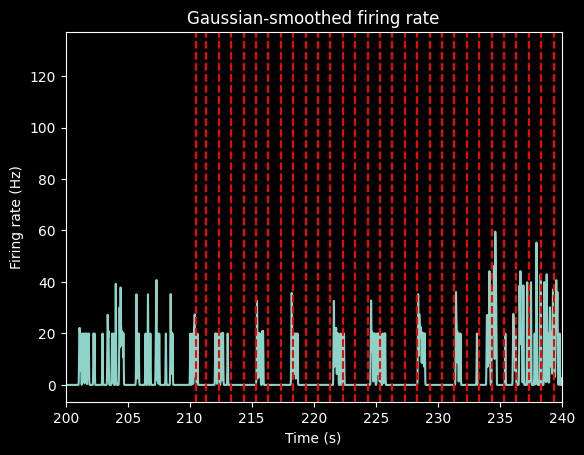

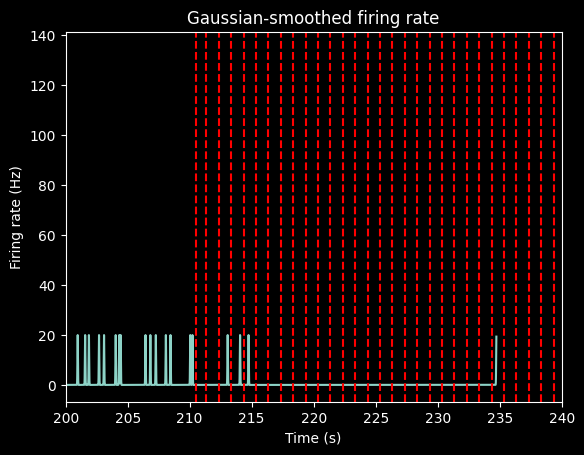

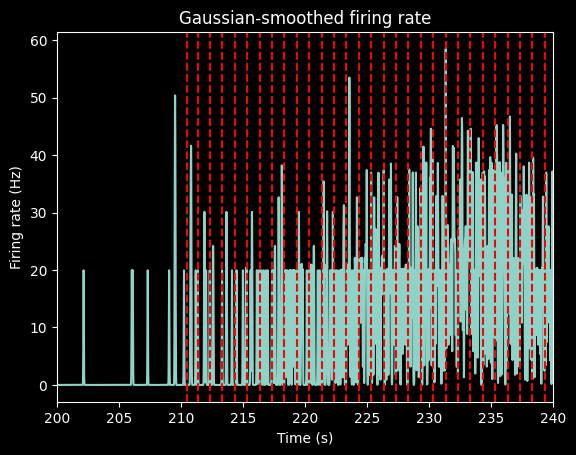

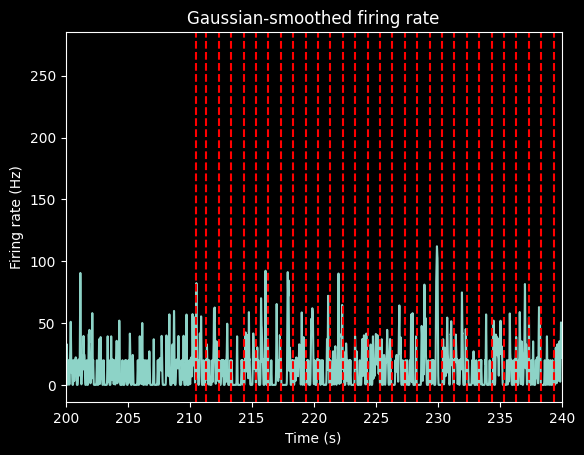

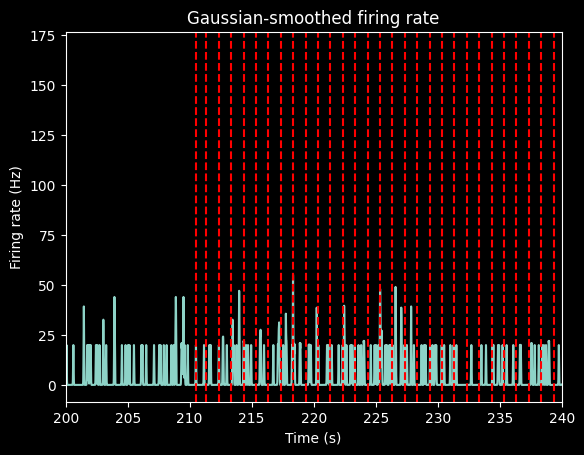

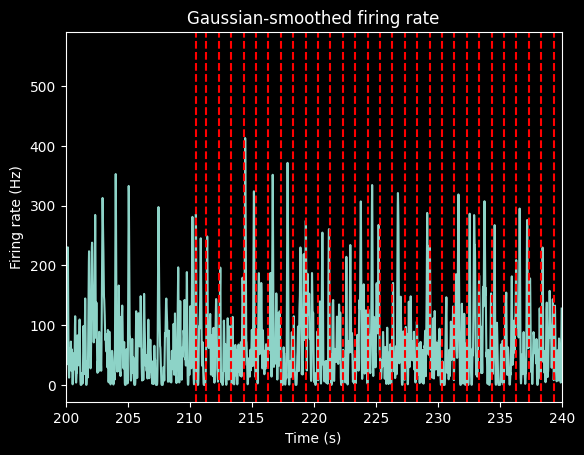

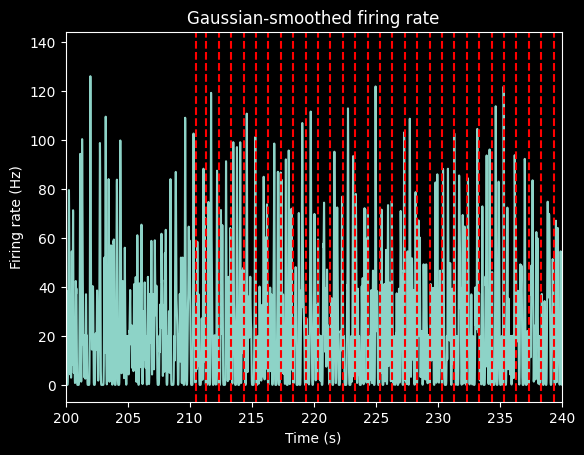

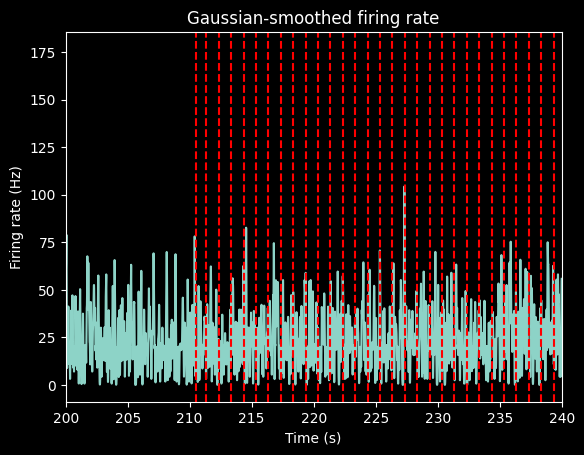

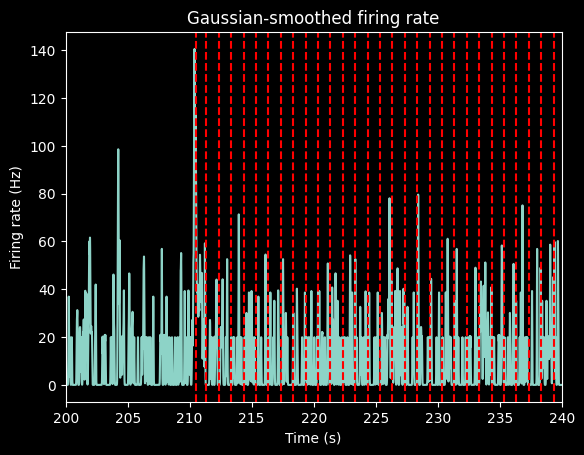

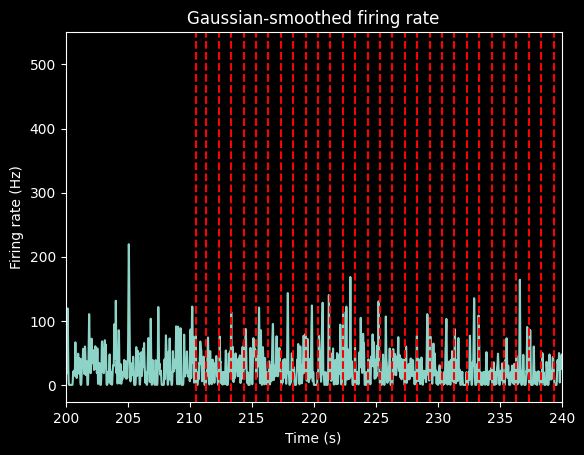

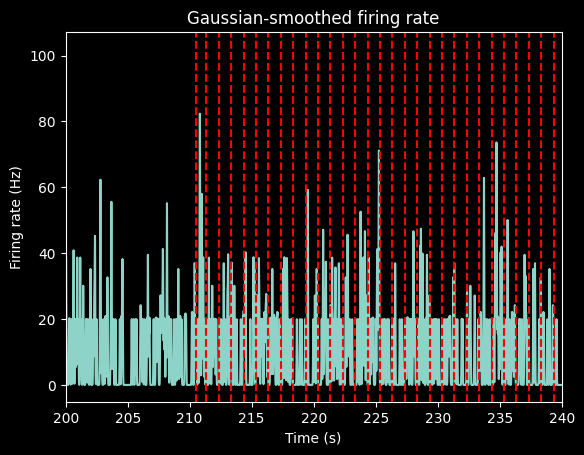

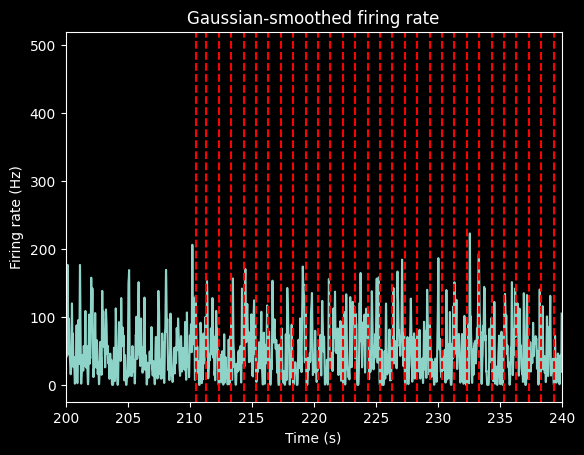

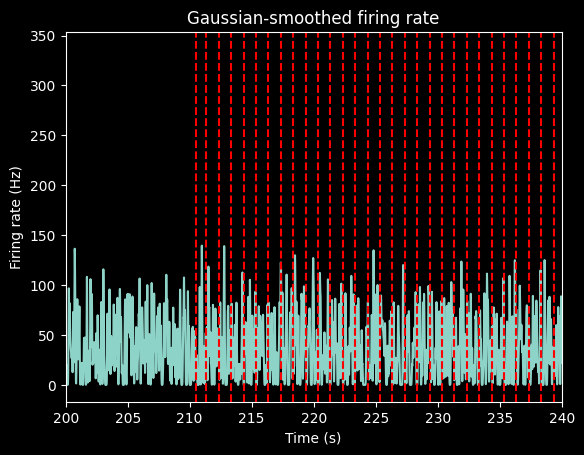

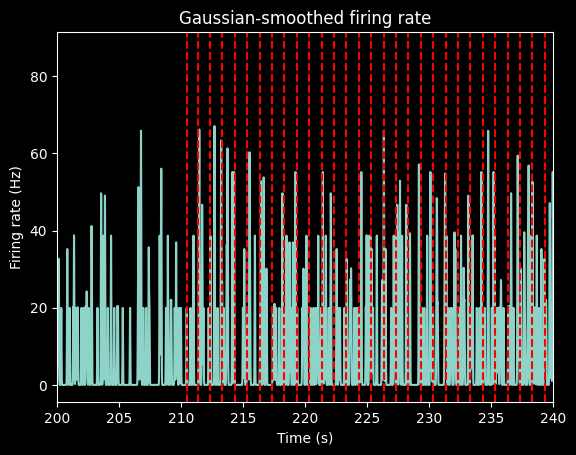

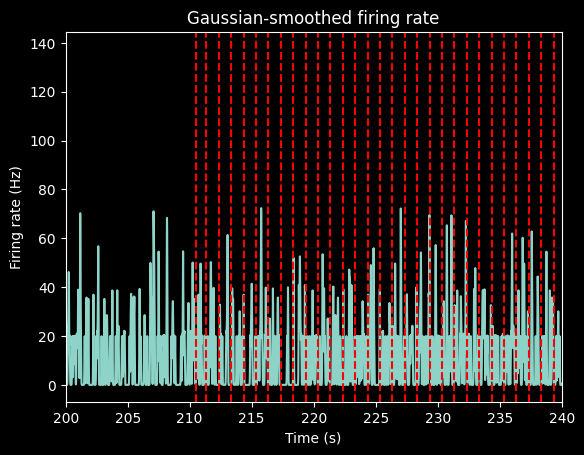

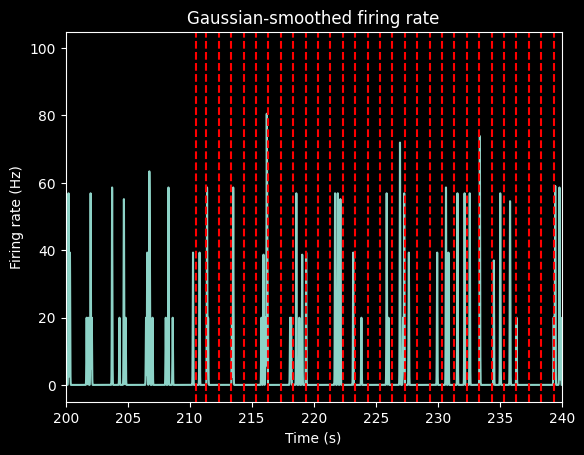

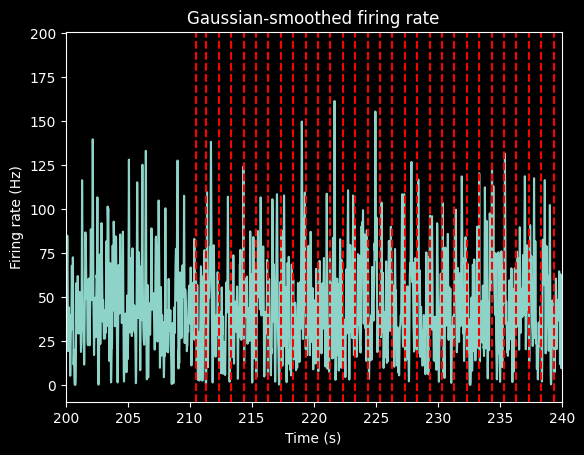

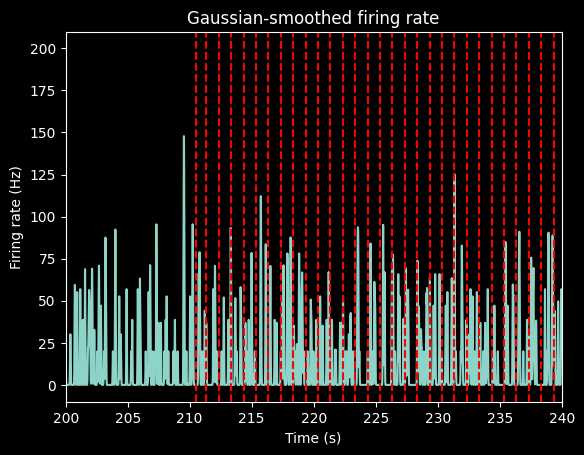

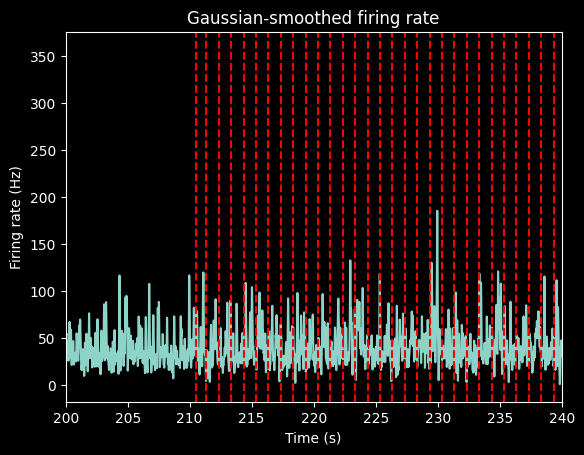

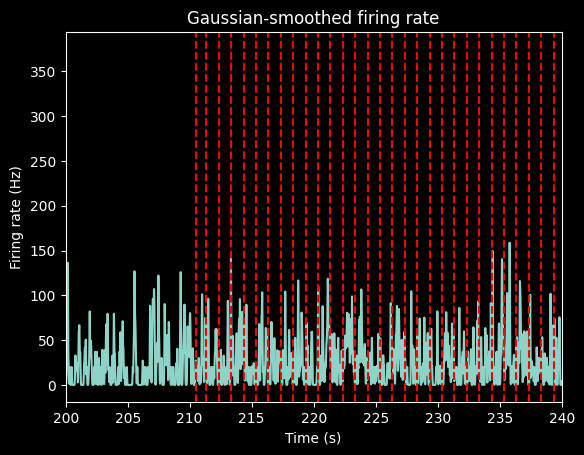

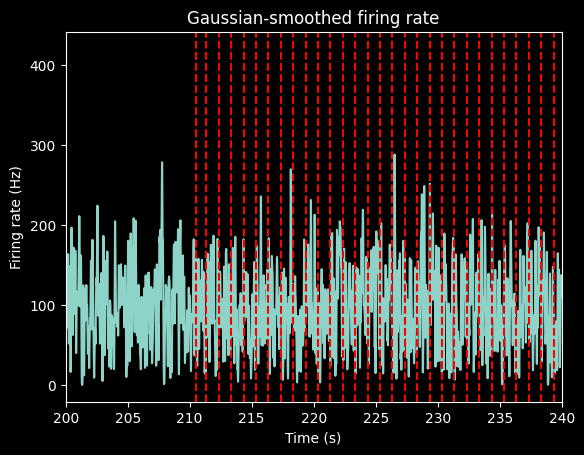

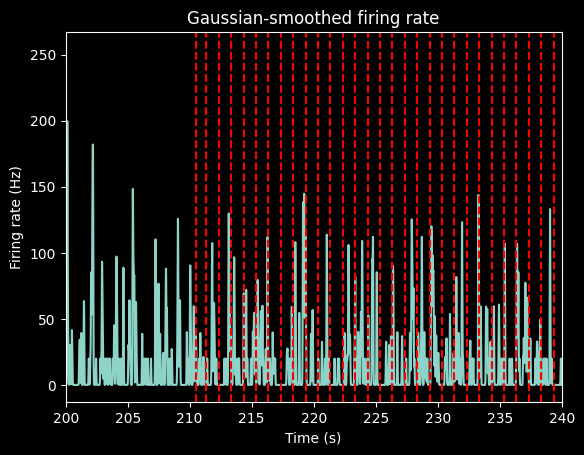

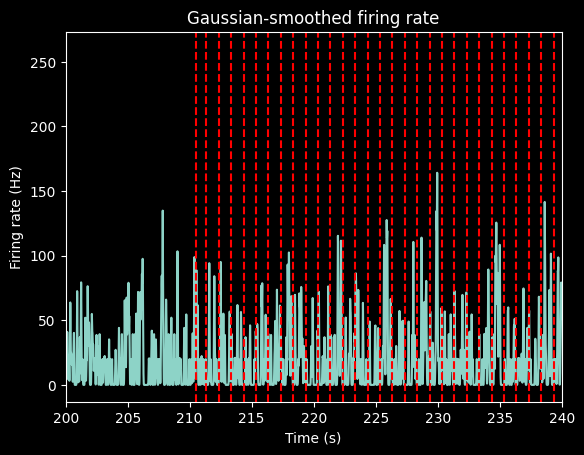

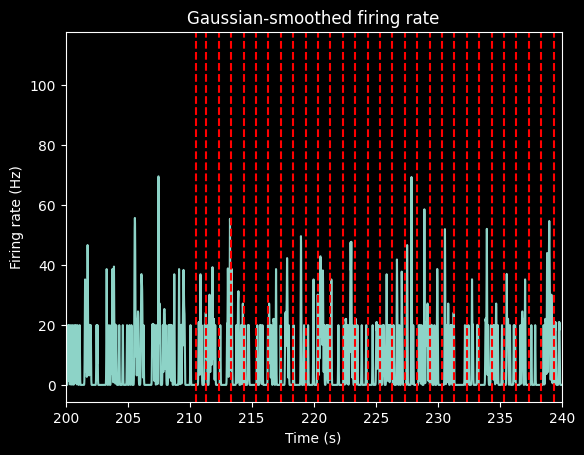

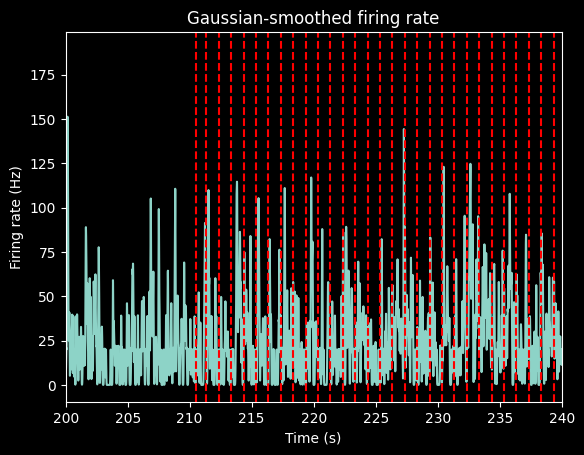

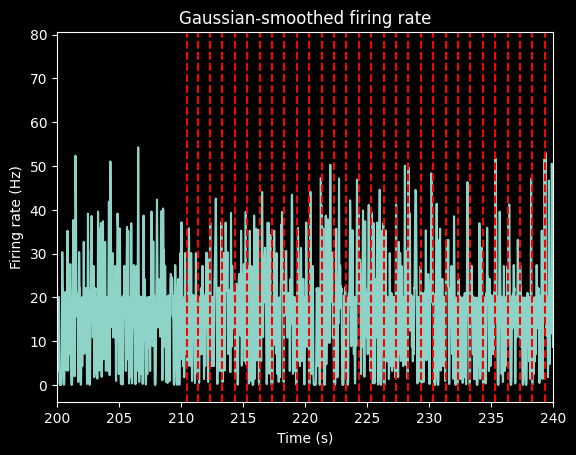

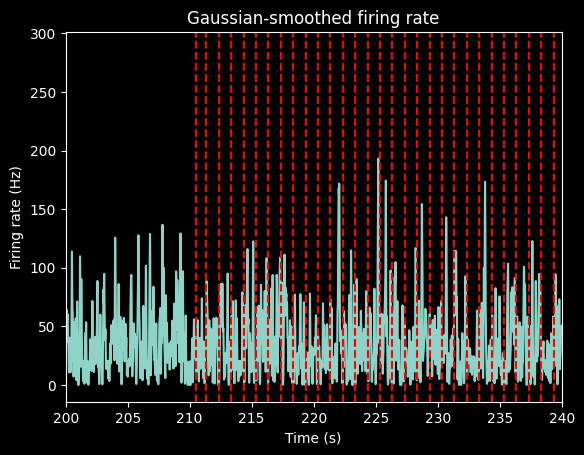

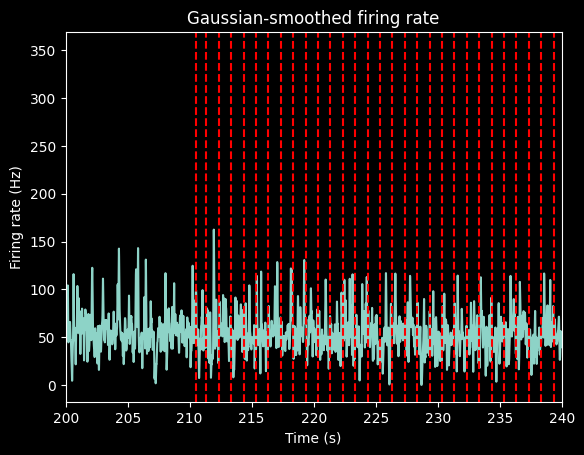

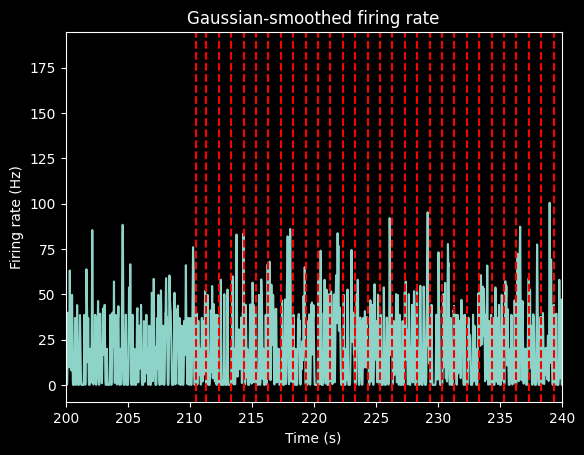

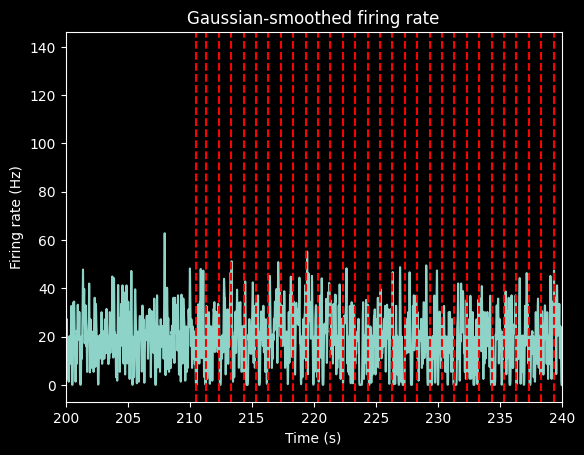

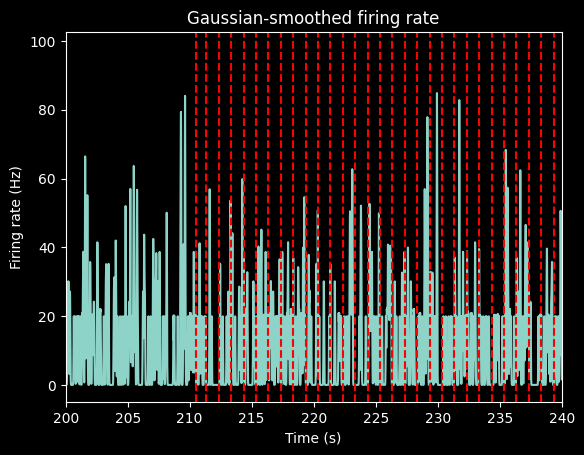

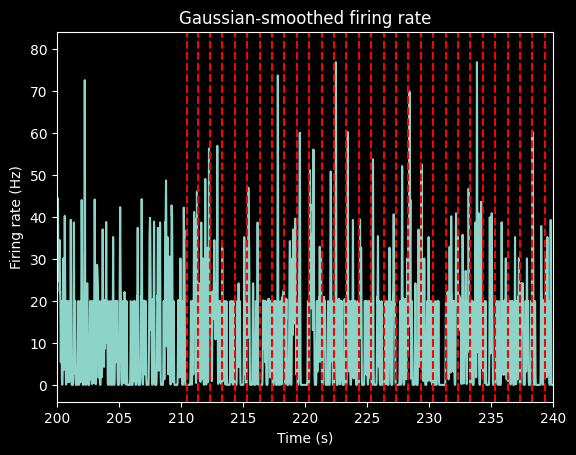

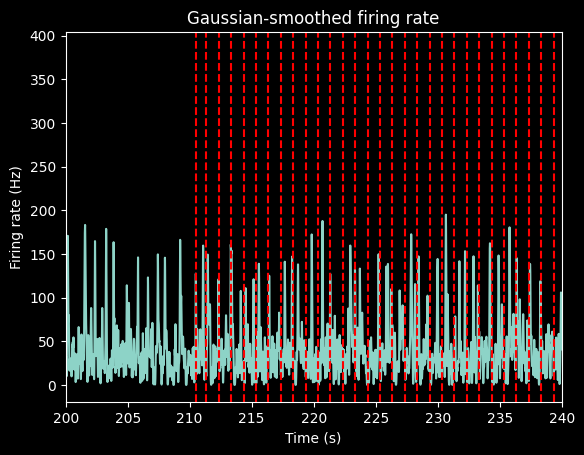

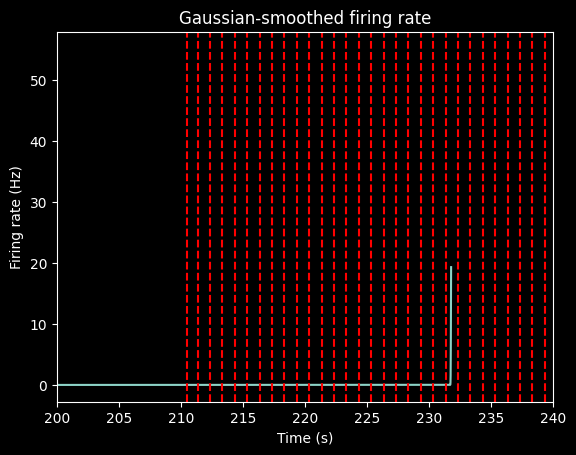

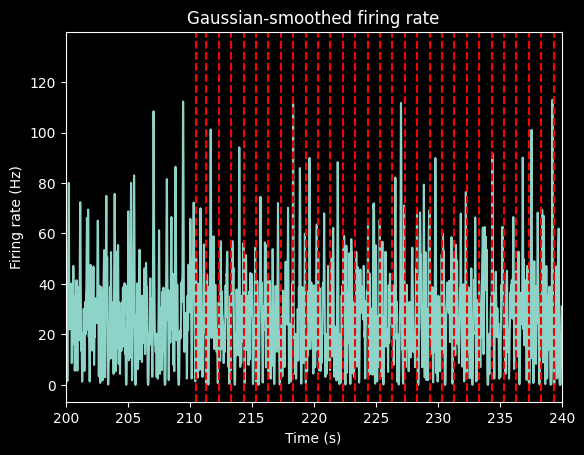

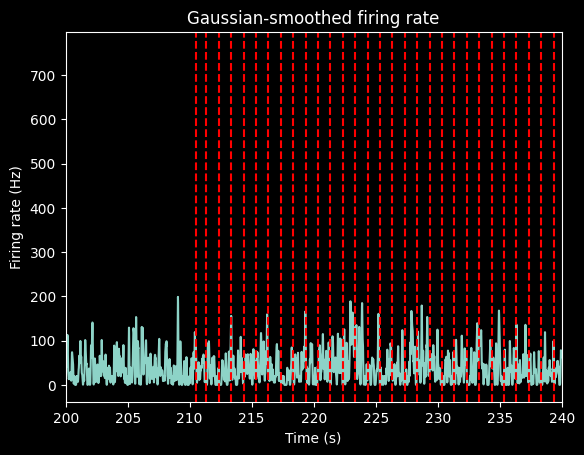

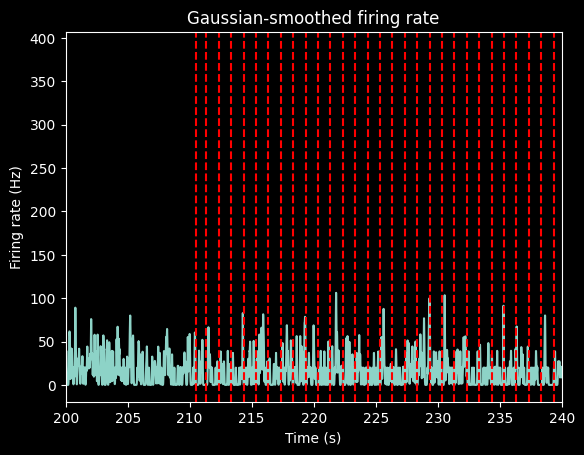

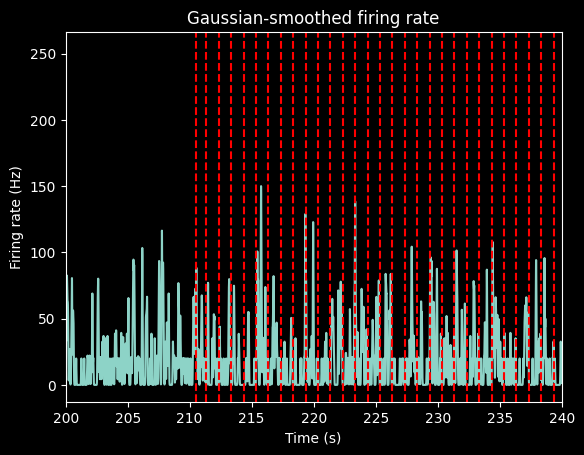

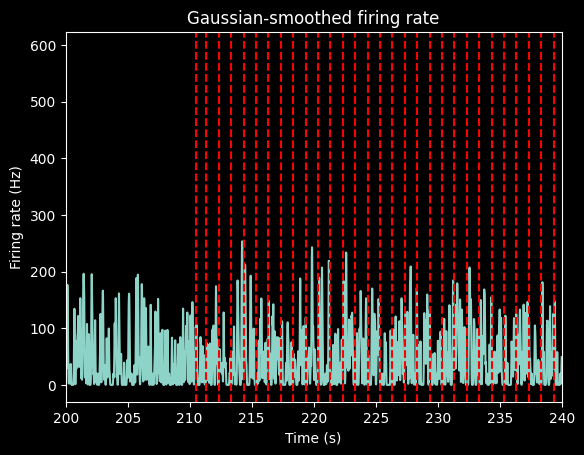

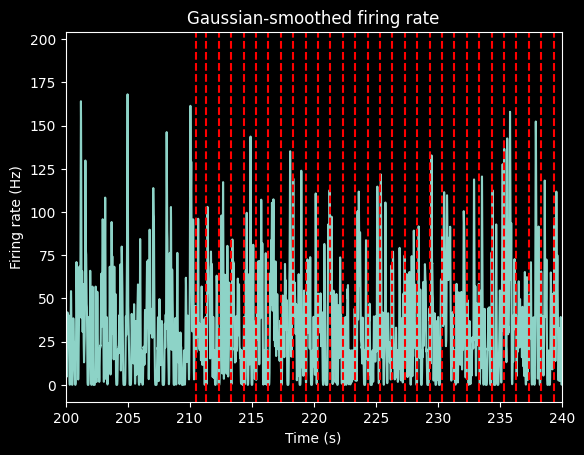

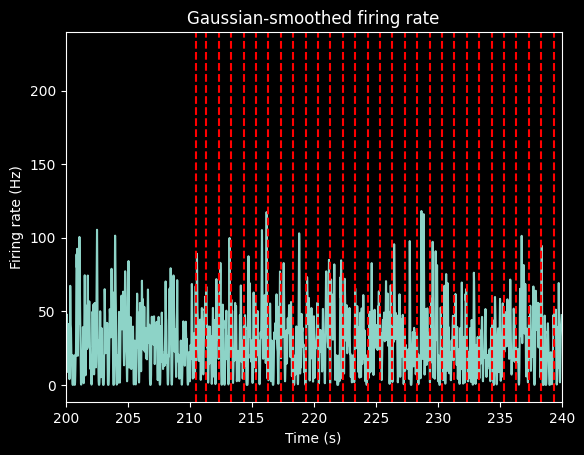

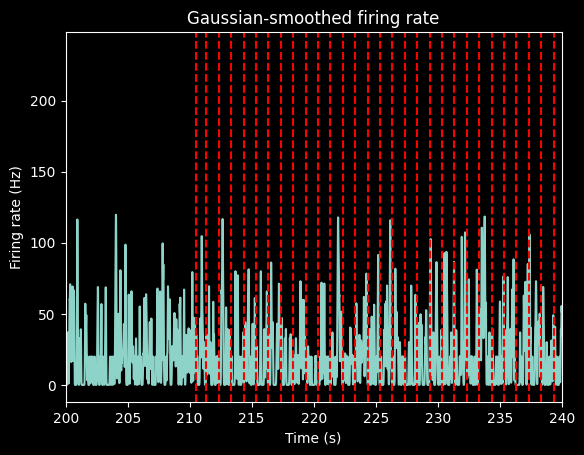

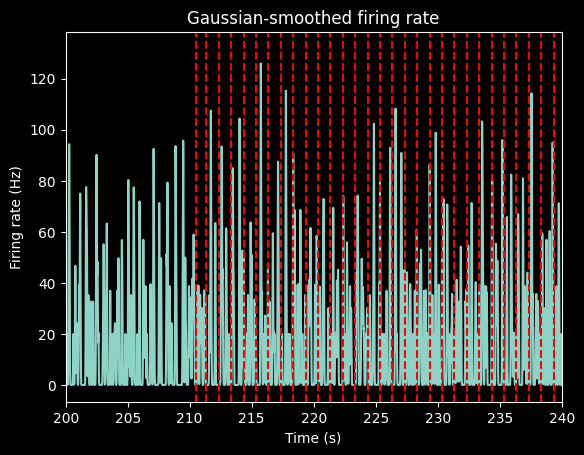

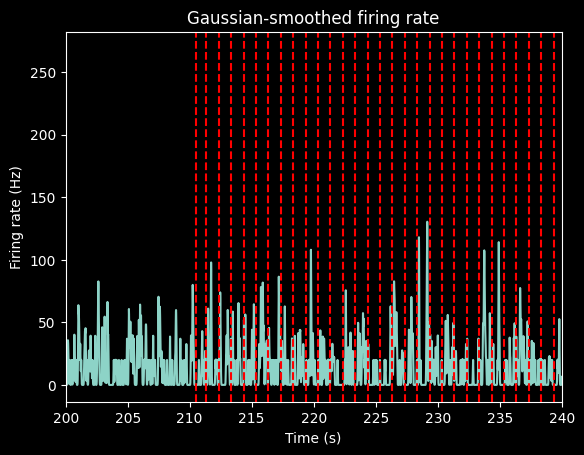

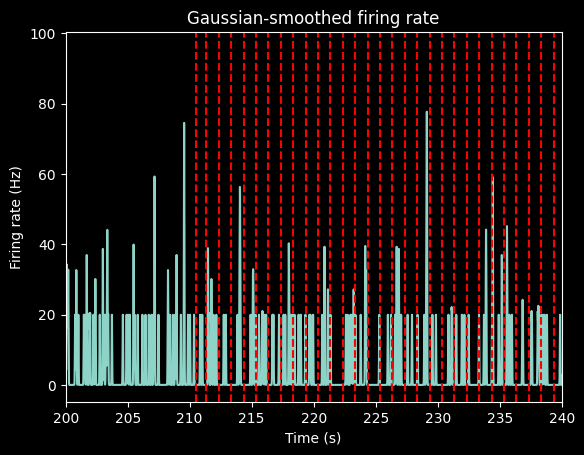

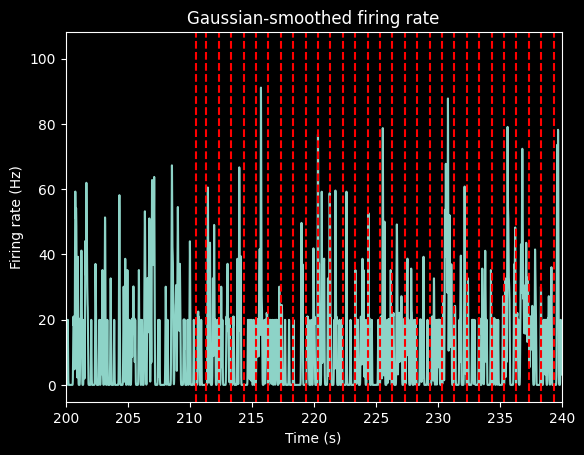

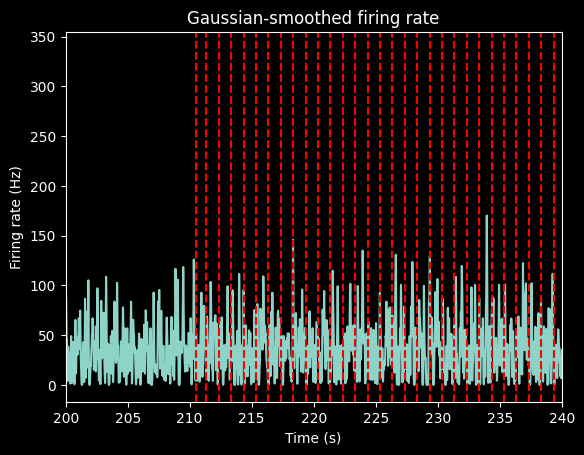

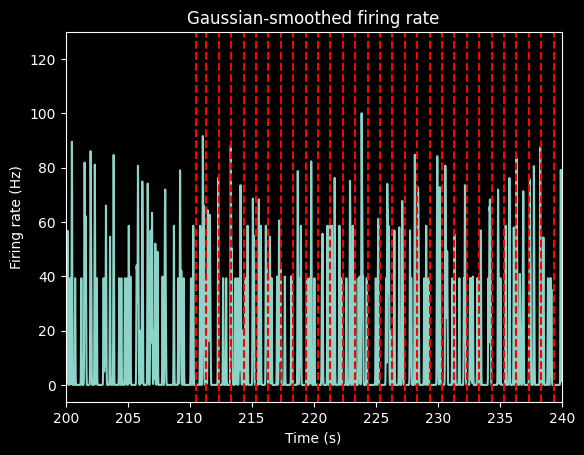

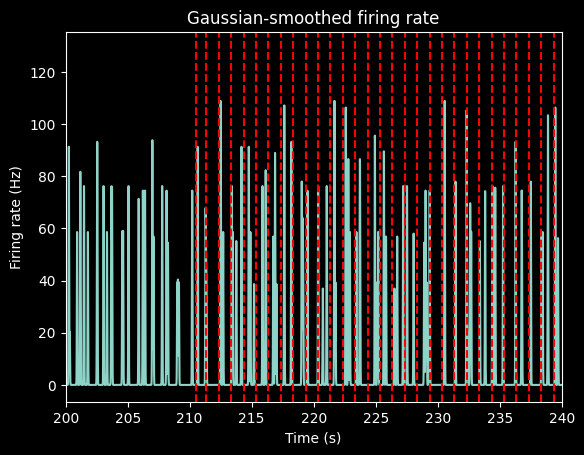

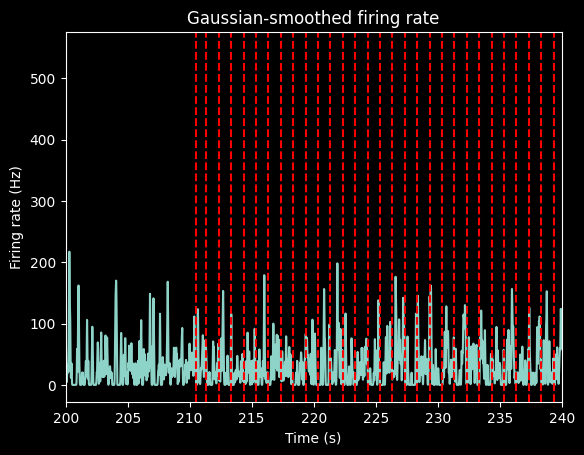

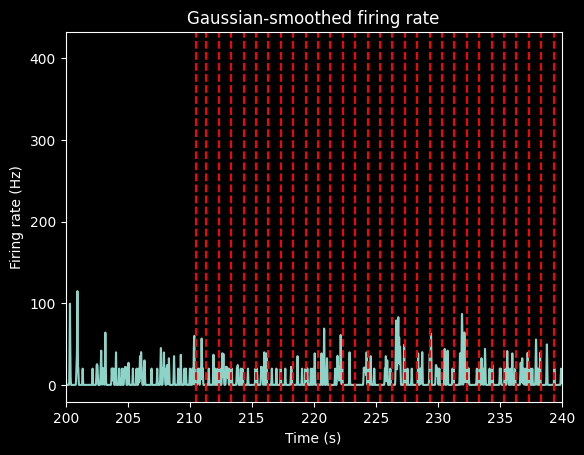

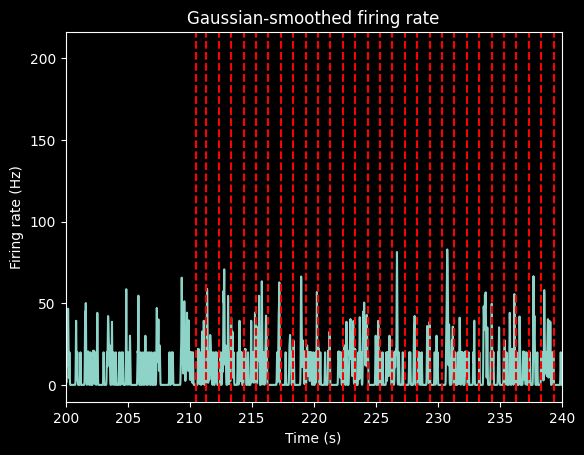

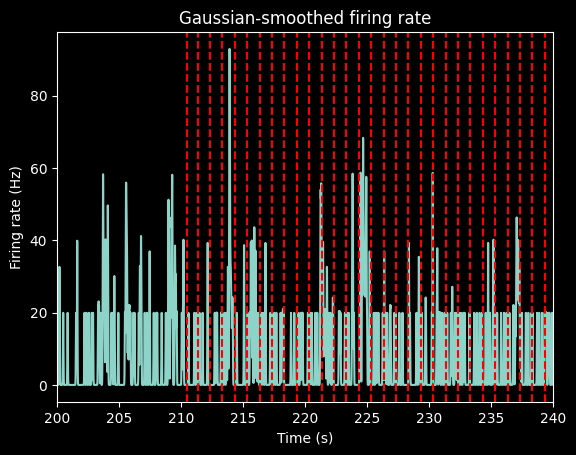

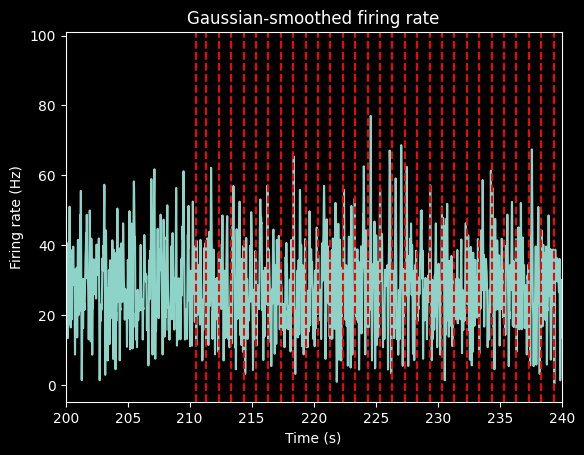

In [41]:
from utils import load_obj, make_figure, run_job, update_subplot_titles, save_fig
from sonogenetics.analysis.lib.analysis_params import dataset_dir, figure_dir_analysis
import matplotlib.pyplot as plt

cluster_id = data_io.cluster_ids[7]
t_pre = 200
t_post = 800


for cid in data_io.cluster_ids:
    # Setup figure layout
    burst_offset = 0
    tid = tdf.iloc[0].train_id
    burst_onsets = data_io.burst_df.query('train_id == @tid').laser_burst_onset.values
    sp = data_io.spiketimes[rec_id][cid]

    t, r = gaussian_firing_rate_ms(sp, dt_ms=5, sigma_ms=20)
    # fig.show()

    # Plot
    plt.figure()
    plt.plot(t, r)
    for onset in burst_onsets:
        plt.axvline(x=onset/ 1000, color='red', linestyle='dashed')

    # print(burst_onsets[0] / 1e3)
    plt.xlim(200, 240)
    plt.xlabel("Time (s)")
    plt.ylabel("Firing rate (Hz)")
    plt.title("Gaussian-smoothed firing rate")
    plt.show()

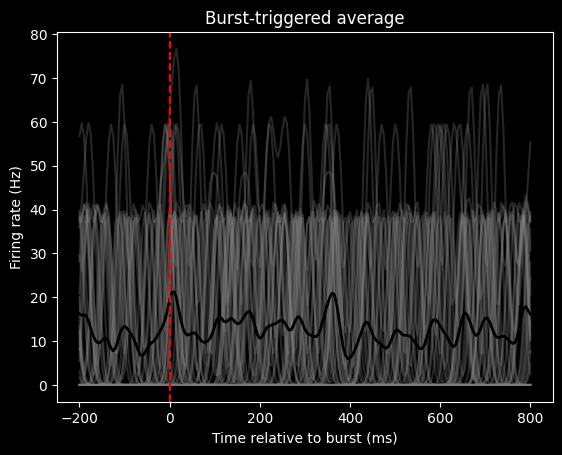

In [28]:
import numpy as np
import matplotlib.pyplot as plt

burst_onsets_s = burst_onsets / 1000.0

t_pre_s = t_pre / 1000.0
t_post_s = t_post / 1000.0

dt = t[1] - t[0]

window_t = np.arange(-t_pre_s, t_post_s, dt)

aligned_responses = []

for onset in burst_onsets_s:
    rel_t = t - onset

    # interpolate firing rate onto fixed window
    segment = np.interp(window_t, rel_t, r)

    aligned_responses.append(segment)

aligned_responses = np.array(aligned_responses)

bta = aligned_responses.mean(axis=0)

plt.figure()

for trial in aligned_responses:
    plt.plot(window_t * 1000, trial, color='gray', alpha=0.3)

plt.plot(window_t * 1000, bta, color='black', linewidth=2)

plt.axvline(0, color='red', linestyle='dashed')

plt.xlabel("Time relative to burst (ms)")
plt.ylabel("Firing rate (Hz)")
plt.title("Burst-triggered average")

plt.show()